# Computer Exercise 1.1 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 1.1 Introduction — Central-Difference Formula
> **풀이 일자**: Day 01
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **3.** *(Continuation)* As we saw in the computer experiment *First*, the accuracy of a formula for numerical
> differentiation may deteriorate as the step size $h$ decreases. Study the following **central-difference formula**:
> $$
> f'(x) \;\approx\; \frac{f(x+h) - f(x-h)}{2h}
> $$
> as $h \to 0$. We learn in Section 4.3 that the truncation error for this formula is
> $-\tfrac{1}{6} f'''(\xi)\, h^2$ for some $\xi \in (x-h,\, x+h)$.
> Modify and run the code for the experiment *First* so that **approximate values for the rounding error and
> truncation error are computed**. On the same graph, plot the **rounding error**, the **truncation error**, and
> the **total error** using a log-scale; that is, the axes in the plot should be $-\log_{10} \text{(error)}$
> versus $\log_{10} h$. Analyze these results.

### 한국어 풀이용 정리
1, 2번 문제와 달리 이번엔 **중심차분(central difference)** 을 사용한다. 절단오차의 차수가 $\mathcal{O}(h^2)$ 로 한 차원 더 빨라진다는 점이 핵심이다.
또한 그래프에 *측정 오차* 만 그리는 것이 아니라, **절단오차 모델**, **반올림오차 모델**, 그리고 둘의 **합(총오차 모델)** 을 함께 그려서 실측과 비교한다.


## 2. 수학적 배경

### 2.1 중심차분의 절단오차
Taylor 전개

$$
f(x \pm h) = f(x) \pm h f'(x) + \tfrac{h^2}{2}f''(x) \pm \tfrac{h^3}{6}f'''(x) + \tfrac{h^4}{24}f^{(4)}(\xi^{\pm}) + \cdots
$$

두 식을 빼면 짝수차 항이 사라진다:

$$
f(x+h) - f(x-h) = 2h f'(x) + \tfrac{h^3}{3}f'''(\xi) + \mathcal{O}(h^5).
$$

따라서

$$
\boxed{\;\frac{f(x+h) - f(x-h)}{2h} \;=\; f'(x) \;-\; \tfrac{h^2}{6}f'''(\xi)\;}
$$

즉 절단오차 $E_{\text{trunc}}(h) \approx \tfrac{h^2}{6}|f'''(x)| = \mathcal{O}(h^2)$. 전진차분의 $\mathcal{O}(h)$ 보다 한 차수 더 빠르게 0으로 간다.

### 2.2 중심차분의 반올림오차
$f(x \pm h)$ 각각이 $\sim \varepsilon_{\text{mach}} \cdot |f(x)|$ 만큼의 오차를 가지므로, 분자 차이의 오차는 약 $2\varepsilon_{\text{mach}} |f(x)|$. 이를 $2h$로 나누면

$$
E_{\text{round}}(h) \;\approx\; \frac{\varepsilon_{\text{mach}}\, |f(x)|}{h} \;=\; \mathcal{O}(h^{-1}).
$$

전진차분과 차수는 같지만, 분자가 $2\varepsilon \to \varepsilon$ 로 절반이라 상수만 약간 작다.

### 2.3 총오차와 최적 $h^*$

$$
E_{\text{total}}(h) \;\approx\; \frac{h^2}{6}|f'''(x)| + \frac{\varepsilon_{\text{mach}}|f(x)|}{h}.
$$

$dE/dh = 0$ 에서

$$
h^*_{\text{central}} \;\approx\; \left(\frac{3\,\varepsilon_{\text{mach}}\,|f(x)|}{|f'''(x)|}\right)^{1/3}
\;\sim\; \varepsilon_{\text{mach}}^{1/3} \;\approx\; 6 \times 10^{-6}.
$$

이때 도달 가능한 **최소 오차의 차수**는 $\varepsilon_{\text{mach}}^{2/3} \approx 4 \times 10^{-11}$.
즉 전진차분의 한계 $\sim 10^{-8}$ 보다 약 1000배 더 정확.


## 3. 풀이 흐름

1. 함수 선택: $f(x) = \sin x$, 평가점 $x = 0.5$ (CE 1.1.1과 동일).
2. $h_i = 4^{-i}$, $i = 1, \ldots, 30$.
3. 각 $h$에서:
   - 중심차분 근사 $y_i = (\sin(x+h)-\sin(x-h))/(2h)$
   - **측정 오차** $|f'(x) - y_i|$
   - **모델 절단오차** $\tfrac{h^2}{6}|f'''(x)|$, where $f'''(x) = -\cos(x)$
   - **모델 반올림오차** $\varepsilon_{\text{mach}} \cdot |f(x)|/h$
   - **모델 총오차** = 절단 + 반올림
4. 한 log-log 그래프에 4개 곡선 (실측 / 절단 / 반올림 / 총합) 같이 그리기.
5. 이론 $h^*$ 와 실측 argmin이 어디서 만나는지 확인.
6. 전진차분 (CE 1.1.1) 결과와 같은 축 위에 비교 — 차수의 차이가 시각적으로 드러나도록.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

x      = 0.5
i_arr  = np.arange(1, 31)
h_arr  = 0.25 ** i_arr
eps    = np.finfo(float).eps

# 참값
fx, fpx, fppx, fpppx = np.sin(x), np.cos(x), -np.sin(x), -np.cos(x)

# 실측 (중심차분)
y_central = (np.sin(x + h_arr) - np.sin(x - h_arr)) / (2 * h_arr)
err_meas  = np.abs(fpx - y_central)

# 모델 오차들
err_trunc = (h_arr**2 / 6) * abs(fpppx)
err_round = eps * abs(fx) / h_arr
err_total = err_trunc + err_round

# 비교: 전진차분 실측
y_fwd     = (np.sin(x + h_arr) - np.sin(x)) / h_arr
err_fwd   = np.abs(fpx - y_fwd)

# 이론 h*
h_star = (3 * eps * abs(fx) / abs(fpppx))**(1/3)
print(f"이론 h*_central ≈ ({h_star:.3e}) ~ ε^(1/3) ≈ {eps**(1/3):.3e}")
imin = int(np.argmin(err_meas) + 1)
print(f"실측 argmin h    = {h_arr[imin-1]:.3e},  min |error| = {err_meas.min():.3e}")

이론 h*_central ≈ (7.139e-06) ~ ε^(1/3) ≈ 6.055e-06
실측 argmin h    = 3.815e-06,  min |error| = 3.562e-12


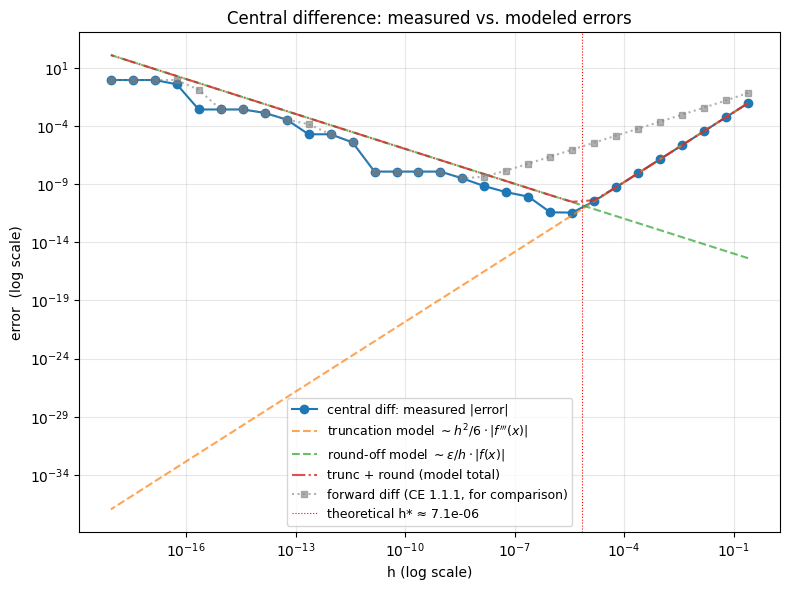

In [2]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.loglog(h_arr, err_meas,  "o-",  label="central diff: measured |error|", color="C0")
ax.loglog(h_arr, err_trunc, "--",  label=r"truncation model $\sim h^2/6 \cdot |f'''(x)|$", color="C1", alpha=0.7)
ax.loglog(h_arr, err_round, "--",  label=r"round-off model $\sim \varepsilon /h \cdot |f(x)|$", color="C2", alpha=0.7)
ax.loglog(h_arr, err_total, "-.",  label="trunc + round (model total)", color="C3", alpha=0.8)
ax.loglog(h_arr, err_fwd,   "s:",  label="forward diff (CE 1.1.1, for comparison)", color="gray", markersize=4, alpha=0.6)

ax.axvline(h_star, color="red", lw=0.8, ls=":", label=f"theoretical h* ≈ {h_star:.1e}")
ax.set_xlabel("h (log scale)")
ax.set_ylabel("error  (log scale)")
ax.set_title("Central difference: measured vs. modeled errors")
ax.legend(loc="best", fontsize=9)
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

In [3]:
# 표로도 정리: i, h, 실측, 절단모델, 반올림모델, 총모델
df = pd.DataFrame({
    "i": i_arr,
    "h": h_arr,
    "measured": err_meas,
    "trunc_model (h^2/6 * |f'''|)": err_trunc,
    "round_model (eps/h * |f|)": err_round,
    "total_model": err_total,
})
pd.set_option("display.float_format", lambda v: f"{v:.3e}")
df

,i,h,measured,trunc_model (h^2/6 * |f'''|),round_model (eps/h * |f|),total_model
0,1,2.500e-01,9.113e-03,9.141e-03,4.258e-16,9.141e-03
1,2,6.250e-02,5.712e-04,5.713e-04,1.703e-15,5.713e-04
2,3,1.562e-02,3.571e-05,3.571e-05,6.813e-15,3.571e-05
3,4,3.906e-03,2.232e-06,2.232e-06,2.725e-14,2.232e-06
4,5,9.766e-04,1.395e-07,1.395e-07,1.090e-13,1.395e-07
5,6,2.441e-04,8.718e-09,8.718e-09,4.360e-13,8.718e-09
6,7,6.104e-05,5.447e-10,5.449e-10,1.744e-12,5.466e-10
7,8,1.526e-05,3.448e-11,3.405e-11,6.977e-12,4.103e-11
8,9,3.815e-06,3.562e-12,2.128e-12,2.791e-11,3.003e-11
9,10,9.537e-07,3.714e-12,1.330e-13,1.116e-10,1.118e-10


## 4. 결과 해석

### 그래프에서 읽어내야 할 것
1. **오른쪽 (큰 $h$)**: `measured` 와 `truncation model` 이 거의 겹쳐 떨어진다 — 기울기 $+2$ → $\mathcal{O}(h^2)$ 절단오차 지배.
2. **왼쪽 (작은 $h$)**: `measured` 와 `round-off model` 이 겹쳐 올라간다 — 기울기 $-1$ → $\mathcal{O}(h^{-1})$ 반올림오차 지배.
3. **중앙 (이론 $h^*$ 근처)**: `total_model` (점선)과 `measured` 가 잘 일치 → 모델이 옳다는 검증.
4. **전진차분과 비교 (회색 점선)**:
   - 같은 $h$에서 중심차분이 항상 더 정확.
   - 최소 오차의 깊이가 약 1000배 차이 (전진 $\sim 10^{-8}$, 중심 $\sim 10^{-11}$).
   - 최적 $h^*$ 위치도 다름: 전진은 $\sqrt{\varepsilon} \approx 10^{-8}$, 중심은 $\varepsilon^{1/3} \approx 10^{-5.5}$ → 중심차분은 더 큰 $h$에서 최적.

### 결론
> **차분 공식의 차수가 한 단계 올라가면, 도달 가능한 정확도는 차원이 다르게 좋아진다.**
> 전진차분: 정확도 한계 $\sim \varepsilon^{1/2}$, 최적 $h \sim \varepsilon^{1/2}$.
> 중심차분: 정확도 한계 $\sim \varepsilon^{2/3}$, 최적 $h \sim \varepsilon^{1/3}$.
> 일반화하면 $p$차 정확도 공식의 최적 $h$ 는 $\varepsilon^{1/(p+1)}$, 도달 한계는 $\varepsilon^{p/(p+1)}$.

### 다음에 다룰 내용 (§4.3 미리보기)
- **Richardson 외삽** 으로 $\mathcal{O}(h^2)$ 중심차분 결과를 두 번 평가해 $\mathcal{O}(h^4)$ 정확도로 끌어올리는 기법.
- 자동 미분(automatic differentiation): 부동소수점 차이를 아예 회피.
